In [8]:
%pip install matplotlib numpy pandas scikit-learn 

Note: you may need to restart the kernel to use updated packages.


## Treinando modelos

Aqui vamos entrar em detalhes de implementação de modelos lineares em grande maioria...

### Regressão Linear

O modelo mais simples possivel para a tarefa de regressão... nele cada predição é dada por uma soma das features ponderada por pesos aprendidos e (se quiser) somado um termo bias. Teriamos que a predição *y_hat = w0.1 + w1.x1 + wn.xn* em que podemos considerar por convenção que a primeira posição do vetor de features vai ser sempre 1 (sendo multiplicado pelo bias). Nessa formulação temos que o a predição *y_hat* é simplesmente o produto interno/escalar do vetor de features *x* e vetor de pesos *w* e *n* é o numero de features. Mas como treinar esse modelo ? 

Primeiramente precisamos medir o quão bem o modelo esta performando e para isso podemos usar o RMSE que é uma versão interpretável da MSE... MSE é o erro médio quadratico, ou seja, calculamos o erro para cada instancia e tiramos a media (no RMSE nos tirariamos a raiz dessa media para voltar a escala original). Otimizar MSE é mais facil que RMSE e elas levam exatamente para o mesmo lugar durante a otimização e portanto a MSE é preferida como métrica de perda.

Agora como encontrar os pesos W tal que minimizem o valor do MSE que é nossa função de qualidade ? Existem algumas maneiras paramétricas de se fazer isso (formula fechada) e não paramétricas através de otimização... 


Paramétricas: 

- Equação Normal: Essa equação é fruto da derivada da MSE igualada a 0 e desenvolvida em função de W (theta). Se tornando a função:

$$
\theta = (X^T X)^{-1} X^T y
$$

Nessa equação precisamos calcular a inversa e se existir colunas com multicolinearidade (fortemente correlacionadas) a matriz chega perto de ser singular (matriz é singular quando suas colunas são linearmente dependentes e consequentemente não é inversivel) e gera numeros instaveis gerando erros numéricos. Além disso, se temos mais features que linhas a matriz será singular e a Normal falha novamente. 

- SVD (LinearRegression do sklearn): Os problemas anteriores são resolvidos através do calculo de uma pseudoinversa usando decomposição SVD:

    - Primeiro decompomos a matriz de features usando SVD em que U (mxm) em que cada coluna é um autovetor no espaço das linhas (amostras)... esse espaço é gerado por XX^t (simétrica) em que cada posição ij dessa matriz representa a proximidade entre a amostra i com amostra j... da mesma maneira V (nxn) é calculado mas no espaço das features X^tX (simétrica) e representa a associação linear entre as features... a matriz do meio são os autovalores V na diagonal principal... os autovetores mostram as direções onde os dados estão mais "espalhados". O autovetor com o maior autovalor é a direção da informação mais importante do seu dataset.:

    $$
    X = U \Sigma V^T
    $$ 

    - Calculamos a pseudoinversa usando a matriz diagonal com os valores não nulos invertidos:

    $$
    X^+ = V \Sigma^+ U^T
    $$

    - Usamos a pseudoinversa para calcular os parametros.

    $$
    \hat{\theta} = X^+ y = V \Sigma^+ U^T y
    $$

Complexidade dos algoritmos: Na equação normal é necessário calcular a inversa da matriz X com n features e isso tem complexidade de O(n³) enquanto o SVD tem complexidade de O(m*n²). Ou seja, esses algoritmos não escalam tão bem quando o numero de features é muito grande (100000 por exemplo) e podem se tornar lentos. Entretanto, as equações escalam muito bem em relação ao tamanho do dataset (linhas) sendo ambos linear em relação a m linhas. Isso é muito util mas e em caso em que o dataset não cabe em memória ? e em casos que temos muitas colunas ?



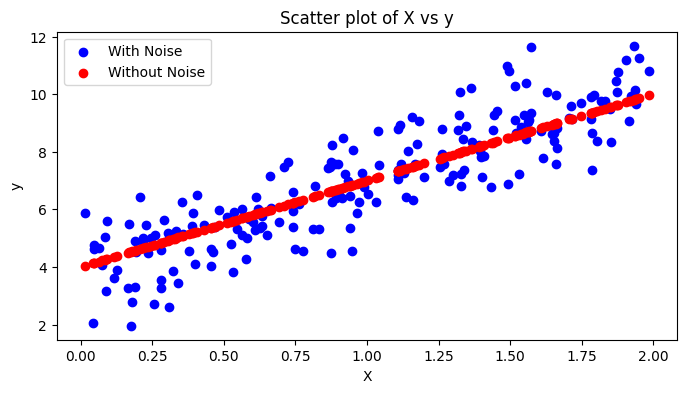

Theta best (com ruído): [[3.69084138]
 [3.32960458]]
Theta best (sem ruído): [[4.]
 [3.]]
Theta best (com ruído, regressão linear do sklearn): [np.float64(3.6908413834642553), np.float64(3.3296045821528386)]
Theta best (com ruído, lstsq): [[3.69084138]
 [3.32960458]]


In [9]:
import numpy as np
rng = np.random.default_rng(seed=42)
m = 200 
X = 2 * rng.random((m, 1)) # 200 rows, 1 column
y_noise = 4 + 3 * X + rng.standard_normal((m, 1)) # y = 4 + 3X + noise

# quanto mais ruido maior a variancia dos dados, mais dificil de encontrar a linha de regressão
# conseguimos encontrar a linha de regressão, mas ela não será tão precisa quanto a linha sem ruído
# quanto menor o dataset, mais difícil de encontrar a linha de regressão, pois o modelo tem menos dados para aprender

y_not_noise = 4 + 3 * X # y = 4 + 3X without noise

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.scatter(X, y_noise, color='blue', label='With Noise')
plt.scatter(X, y_not_noise, color='red', label='Without Noise')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Scatter plot of X vs y")
plt.legend()
plt.show()

# Equação Normal:

X_b = np.c_[np.ones((m, 1)), X] # Adiciona x0 = 1 para cada instância
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_noise) # Calcula os melhores parâmetros usando a equação normal
print("Theta best (com ruído):", theta_best)

theta_best_no_noise = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_not_noise) # Calcula os melhores parâmetros sem ruído
print("Theta best (sem ruído):", theta_best_no_noise)

from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y_noise) # Treina o modelo com os dados com ruído
print("Theta best (com ruído, regressão linear do sklearn):", [lin_reg.intercept_[0], lin_reg.coef_[0][0]])

theta_lstsq = np.linalg.lstsq(X_b, y_noise, rcond=None)[0] # Calcula os melhores parâmetros usando a função lstsq do NumPy
print("Theta best (com ruído, lstsq):", theta_lstsq)

#### Gradiente Descendente

Gradiente Desc. é um algoritmo de otimização que trabalha se movimentando no espaço n-dimensional gerado pelos parâmetros do modelo, ou seja, os pesos *w* de tamanho *n*. O algoritmo começa em um ponto aleatório normalmente com random inicialization e apartir de lá começa a dar passos de tamanho *alpha* (learning rate) na direção oposta do vetor gradiente. O vetor gradiente é um vetor no espaço dos parametros, ou seja, se o modelo tem 2 parametros então o vetor gradiente esta em R² e é algo como [0,1]... esse vetor é composto pelas derivadas parciais da Loss (MSE por exemplo) em relação aos parametros, então se temos um vetor de parametros *w* = [w0,w1], o vetor gradiente do espaço dos parametros serão as derivadas parciais *[dJ/dw0, dJ/dw1]* (essas coordenadas são calculadas com base no ponto do espaço de parametros que estamos agora, ou seja, usamos os parametros atuais para calcular essas derivadas). Cada uma dessas derivadas diz algo como: nesse ponto se mantermos todos os outros parametros fixos e aumentarmos w0 teremos um aumento da loss de dJ/dw0. O vetor gradiente é composto por essas derivadas e aponta para a direção de maior crescimento da função de Loss... uma vez que queremos minimizar a função de Loss nos usamos o negativo do vetor gradiente. A equação usada para atualização dos parametros atuais (se mover no espaço) é: 

$$
\theta_{j} := \theta_{j} - \alpha \frac{\partial}{\partial \theta_{j}} J(\theta_0, \theta_1, ..., \theta_n)
$$
Forma vetorial:
$$
\theta := \theta - \alpha \nabla_{\theta} J(\theta)
$$

Repare que o quanto os parametros são alterados em cada epoca depende de 2 coisas: O gradiente parcial do parâmetro j que representa que se aumentarmos o parametro a loss ira descer ou subir uma quantidade, ou seja, se estamos em uma descida ou subida e o quao ingrime ela é... O outro fator é *alpha* que controla o tamanho do passo que vamos dar na direção contrária do vetor gradiente, ou melhor, na direção contrária do crescimento da loss naquele parametros. Se *alpha* é muito baixo nossa convergencia (chegar no minimo) vai acontecer mais lentamente uma vez que estamos dando passos curtos, em contrapartida se ele for muito alto pode ser que o modelo nem mesmo chegue a convergir pois pode acontecer de dele começar a encontrar pontos muito ingrimes que façam a alteração do parametro ser tão brusca que pula os vales e começa a super indefinidamente... Além disso, nem mesmo com *alphas* bons a convergencia é garantida já que existem minimos locais e globais em funções não convexas (MSE é uma função convexa e que o conceito é que para qualquer 2 pontos que escolhermos a função estara em baixo da linha que conecta esses dois pontos (não convexa pode ser convexa em um intervalo)). Um minimo é global quando não existe nenhum ponto na função menor que ele... e o gradiente descendente não garante minimo global para funções não convexas. Se uma função tiver platos (regiões "planas") o algoritmo também fica estagnado uma vez que o gradiente será 0. Uma forma interessante de ver a importancia de escalar as variaveis com padronização ou normalização é observar o formato do espaço gerado por variaveis não escaladas e escalas... o espaço escalado tem formato mais comportado que permite o algoritmo encontrar o minimo em menos passos...

![image.png](imagens/scaledvsnot.png)


Grandiente descendente em batch (lote):

Nessa versão do algoritmo nos usamos todos os dados do dataset em cada epoca (iteração) do treinamento, ou seja, se temos 10 iterações nós iremos atualizar os parametros do modelo 10 vezes e em todas vamos usar todo o dataset... essa versão pode ser interessante e mais rapida em convergir para datasets pequenos e medios com muitas features (ponto fraco das soluções paramétricas) mas em datasets com poucas features e muitas linhas ele será extremamente lento. Para encontrar bons parametros de learning rate podemos usar GridSearch ou RandomSearch e explorar varias possibilidades... porém alguns valores de learning rate irão fazer com que o algoritmo demore muito para convergir e isso tomará muito tempo e portanto é interessante limitar o numero de epocas... encontrar um bom numero de epocas pode ser desafiador também já que não sabemos de antemão quando é a hora certa de parar pois se for muito poucas podemos perder tempo e estar longe do minimo mas se for muito grande podemos já estar no minimo e gastar processamento atoa... uma solução para isso é o *early stopping* que usa um parametro *e* chamado tolerancia que é um valor bem pequeno e a cada epoca comparamos o valor da loss antiga com o valor da loss nova e se a diferença entre elas for menor que *e*, paramos o algoritmo pois não tem mais atualização significante. Também é normal usar early stopping com loss da validação que para imediatamente quando a loss da validação para de cair... também é comum manter um máximo de epocas para evitar rodar infinitamente.

Apenas por ilustração essa é a derivada da loss MSE (em forma não vetorial e vetorial) que usamos para calcular os gradientes:

$$
\frac{\partial MSE}{\partial z_i} = -\frac{2}{n} (y_i - z_i)
$$

$$
\nabla_{\mathbf{w}} MSE = -\frac{2}{n} X^T (\mathbf{y} - X\mathbf{w})
$$

In [10]:
import time
# batch gradient descent

n_epochs = 1000
theta = np.random.randn(2, 1) # inicializa os parâmetros aleatoriamente


def batch_gradient_descent(X_b, y, theta, learning_rate, n_epochs):
    for epoch in range(n_epochs):
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y) # calcula os gradientes
        theta = theta - learning_rate * gradients # atualiza os parâmetros

    return theta

for learning_rate in [0.01, 0.1, 0.5]:
    theta = batch_gradient_descent(X_b, y_noise, theta, learning_rate, n_epochs)
    print(f"Theta best (com ruído, batch gradient descent, learning rate={learning_rate}):", theta)

start_time = time.time()

batch_gradient_descent(X_b, y_not_noise, theta, learning_rate=0.1, n_epochs=n_epochs)

end_time = time.time()
print(f"Time taken: {end_time - start_time:.2f} seconds")


Theta best (com ruído, batch gradient descent, learning rate=0.01): [[3.7105372 ]
 [3.31261315]]
Theta best (com ruído, batch gradient descent, learning rate=0.1): [[3.69084138]
 [3.32960458]]
Theta best (com ruído, batch gradient descent, learning rate=0.5): [[6.69036055e+42]
 [7.75520799e+42]]
Time taken: 0.00 seconds


Gradiente Descendente Estocastico:

Nessa versão do algoritmo temos que os parâmetros do modelo não serão alterados apenas uma vez por epoca mas *m* vezes em que *m* é o numero de instancias nos dados de treino. Cada step ele ira atualizar os parametros com base em um unico exemplo do dataset... pode ser uma amostragem aleatória com repetição a cada step (chance de amostrar o mesmo) ou ate mesmo um shuffle e passar por todas as instancias sem repetir nenhuma. Então se temos 10 epocas e 1000 linhas no dados de treino então atualizaremos os parametros 10000 vezes caso colcarmos as iterações para ser igual ao numero de linhas... Essa versão permite treinar modelos em datasets muito grandes uma vez que apenas uma instancia precisara ficar em memória a cada vez, ele também treina mais rapido na maioria dos casos mas o problema principal é que ele é muito instavel já que usamos apenas um exemplo para atualizar os parametros... isso faz com que andamos em diversas direções que nem sempre ajudam a chegar no minimo fazendo com que a loss fique subindo e descendo e impedindo de encontrar uma solução otima. Por outro lado essa instabilidade pode ajudar o algoritmo a fugir de minimos locais com passos grandes inicialmente e passos menores no final... esse processo é chamado de **simulated Aneling** em que usamos uma função de **learning schedule** que controla o quanto o learning rate será reduzido a cada epoca. O shuffle inicial é importante para evitar **vies de inserção** de dados que podem ser adiquiridos na ordem de inserção no banco de dados.

In [21]:
n_epochs = 100
theta = np.random.randn(2, 1) 
lr = 0.01

def learning_sheduling(t):
    return lr / (1 + t / n_epochs)

def stochastic_gradient_descent(X_b, y, theta, learning_rate, n_epochs):
    m = len(X_b)
    for epoch in range(n_epochs):
        lr = learning_sheduling(epoch)
        for i in range(m):
            random_index = np.random.randint(m) # seleciona um índice aleatório
            xi = X_b[random_index:random_index+1] # seleciona a instância correspondente
            yi = y[random_index:random_index+1] # seleciona o rótulo correspondente
            gradients = 2 * xi.T.dot(xi.dot(theta) - yi) 
            theta = theta - lr * gradients 

    return theta

start_time = time.time()

theta = stochastic_gradient_descent(X_b, y_noise, theta, lr, n_epochs)

end_time = time.time()

print(f"Theta best (com ruído, stochastic gradient descent, learning rate={lr}):", theta)
print(f"Time taken: {end_time - start_time:.2f} seconds")


# fazendo no sklearn
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-3, penalty=None, eta0=0.01, learning_rate="invscaling", random_state=42)
sgd_reg.fit(X, y_noise.ravel()) 
print("Theta best (com ruído, stochastic gradient descent do sklearn):", [sgd_reg.intercept_, sgd_reg.coef_[0]])


Theta best (com ruído, stochastic gradient descent, learning rate=0.01): [[0.38344763]
 [3.06808424]]
Time taken: 0.10 seconds
Theta best (com ruído, stochastic gradient descent do sklearn): [array([3.44869091]), np.float64(1.074590531941348)]


Gradiente em Mini-Batch:

Essa versão do algoritmo serve de intermediária entre batch e estocastica uma vez que ao inves de atualizar os parametros a cada instancia ou com todas as instancias ele usa um subconjunto aleatório dos dados... os dados são divididos em *k* mini-batchs de tamanho *m/k* e os parametros são atualizados k vezes a cada epoca... A principal vantagem do mini batch é o fato de ser possivel a paralelização usando CPUs ou GPUs. Também é mais estavel pois a direção de atualização leva em consideração bem mais amostras e pode ser treinado mesmo que o dataset não caiba em memória pois é só reduzir o batch_size. Em geral o SGD e MBGD são mais rapidos que o em batch pois imagine que você tem 1.000 GPUs:

- Estratégia Batch: Você usa as 1.000 GPUs para processar o dataset inteiro e dá 1 passo perfeito.
- Estratégia Mini-batch: Você usa cada GPU (ou grupos pequenos) para processar mini-batches e dá 1.000 passos "bons o suficiente".

Matematicamente, em problemas de otimização convexos e não-convexos, dar 1.000 passos aproximados leva você muito mais longe do que dar 1 passo perfeito, mesmo que o tempo total de relógio para processar os dados seja o mesmo. Eles convergem mais rapido pois dão mais passos em direção em menor tempo e se usarem learning schedule convergem no otimo.

![image.png](imagens/batch.png)

Em algoritmos de mini-batch e estocastico, parar o treino quando o erro de validação subir não é o ideal uma vez que eles ocilam bastante devido a aleatoriedade do batch. Idealmente esperamos algumas epocas seguidas de subida chamada de tolerancia... O batch converge sozinho mas o mini e estocastico não por causa das ocilações... para fazer eles convergirem a um learnig schedule ajuda.

In [12]:
# mini-batch gradient descent

def mini_batch_gradient_descent(X_b, y, theta, learning_rate, n_epochs, batch_size):
    m = len(X_b)
    for epoch in range(n_epochs):
        indices = np.random.permutation(m) # embaralha os índices
        X_b_shuffled = X_b[indices] # embaralha os dados
        y_shuffled = y[indices] # embaralha os rótulos
        for i in range(0, m, batch_size):
            xi = X_b_shuffled[i:i+batch_size] # seleciona um mini-batch de instâncias
            yi = y_shuffled[i:i+batch_size] # seleciona os rótulos correspondentes
            gradients = 2/len(xi) * xi.T.dot(xi.dot(theta) - yi) 
            theta = theta - learning_rate * gradients 

    return theta

start_time = time.time()

theta = mini_batch_gradient_descent(X_b, y_noise, theta, lr, n_epochs, batch_size=20)
end_time = time.time()

print(f"Theta best (com ruído, mini-batch gradient descent, learning rate={lr}):", theta)
print(f"Time taken: {end_time - start_time:.2f} seconds")

Theta best (com ruído, mini-batch gradient descent, learning rate=0.01): [[3.69321454]
 [3.32771701]]
Time taken: 0.01 seconds


### Regressão Polinomial

Para criar modelos mais complexos nao lineares podemos aumentar o grau das features, ou seja, ao inves de usar x usamos x^2 ou x^3... o scikitlearn tem algo que facilita isso criando combinacoes polinomiais das suas features antes de mandar para o modelo. (cuidado pois o scikit cria muitas combinacoes que podem explodir rapido em quantidade). Além disso, graus muito altos (modelo muito complexo) pode facilmente levar a overfitting.

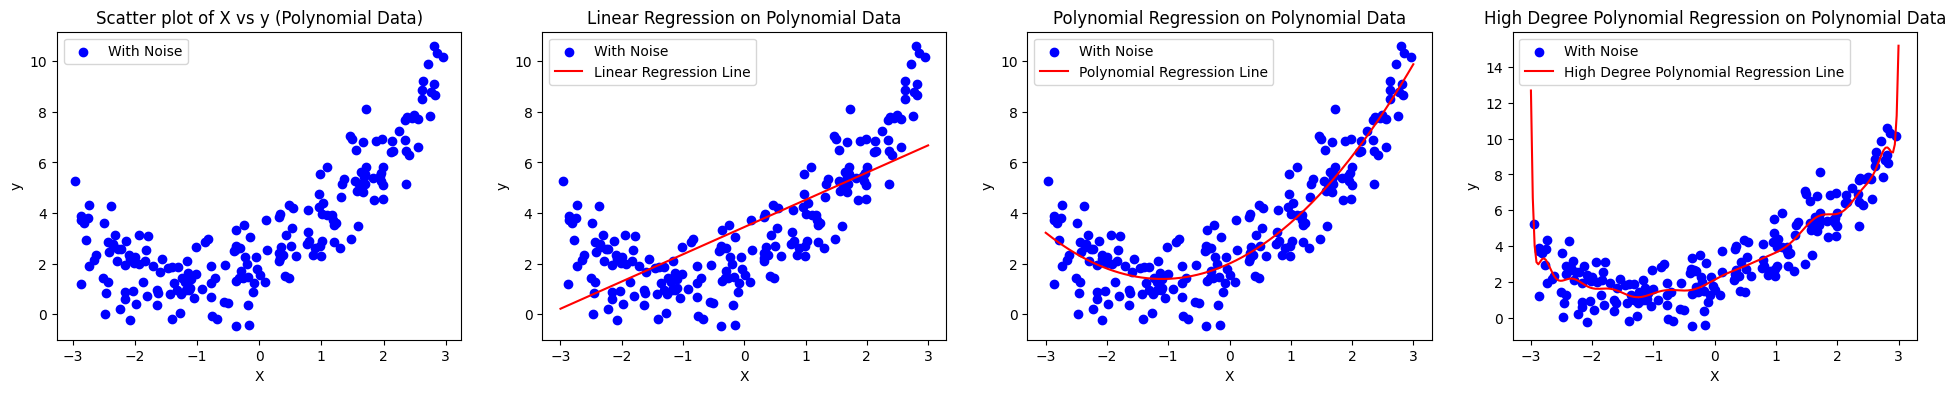

In [13]:
# dados polinomiais
rng = np.random.default_rng(seed=42)
m = 200

X = 6* rng.random((m, 1)) - 3
y_noise = 2 + X + 0.5 * X**2 + rng.standard_normal((m, 1)) 


fig, axes = plt.subplots(1,4,figsize=(24, 4))

axes[0].scatter(X, y_noise, color='blue', label='With Noise')
axes[0].set_xlabel("X")
axes[0].set_ylabel("y")
axes[0].set_title("Scatter plot of X vs y (Polynomial Data)")
axes[0].legend()

X_new = np.linspace(-3, 3, 200).reshape(-1, 1)

# linha da regressão linear
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y_noise)
y_predict = lin_reg.predict(X_new)
axes[1].scatter(X, y_noise, color='blue', label='With Noise')
axes[1].plot(X_new, y_predict, color='red', label='Linear Regression Line')
axes[1].set_xlabel("X")
axes[1].set_ylabel("y")
axes[1].set_title("Linear Regression on Polynomial Data")
axes[1].legend()

# linha da regressão polinomial
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly, y_noise)
X_new_poly = poly_features.transform(X_new)
y_predict_poly = lin_reg_poly.predict(X_new_poly)

axes[2].scatter(X, y_noise, color='blue', label='With Noise')
axes[2].plot(X_new, y_predict_poly, color='red', label='Polynomial Regression Line')
axes[2].set_xlabel("X")
axes[2].set_ylabel("y")
axes[2].set_title("Polynomial Regression on Polynomial Data")
axes[2].legend()

# linha da regressão polinomial com muitos graus
poly_features_high_degree = PolynomialFeatures(degree=20, include_bias=False)
X_poly_high_degree = poly_features_high_degree.fit_transform(X)
lin_reg_poly_high_degree = LinearRegression()   
lin_reg_poly_high_degree.fit(X_poly_high_degree, y_noise)
X_new_poly_high_degree = poly_features_high_degree.transform(X_new)
y_predict_poly_high_degree = lin_reg_poly_high_degree.predict(X_new_poly_high_degree)
axes[3].scatter(X, y_noise, color='blue', label='With Noise')
axes[3].plot(X_new, y_predict_poly_high_degree, color='red', label='High Degree Polynomial Regression Line')
axes[3].set_xlabel("X")
axes[3].set_ylabel("y")
axes[3].set_title("High Degree Polynomial Regression on Polynomial Data")
axes[3].legend()

plt.show()

### Curvas de aprendizado (learning curve)

Essas curvas mostram a evolucao da funcao de perda nos dados de treino e de validacao em relacao a quantidade de dados usados para treinar... se o modelo suporta treino incremental (online learning/gradiente descendente) ele será treinado incrementalmente nos pedacos dos datasets. Se ele nao suportar ele será treinado varias vezes em que cada vez a quantidade de dados maior como por exemplo primeiro 20%, depois 40%, depois 60% ate chegar em todos os dados de treino. Esse conceito é diferente Loss curve (Deep Learning) que plota loss por epoca... na curva de aprendizado conseguimos ver overfitting/underfitting também mas além disso podemo ver se vale a pena ou nao coletar mais dados.

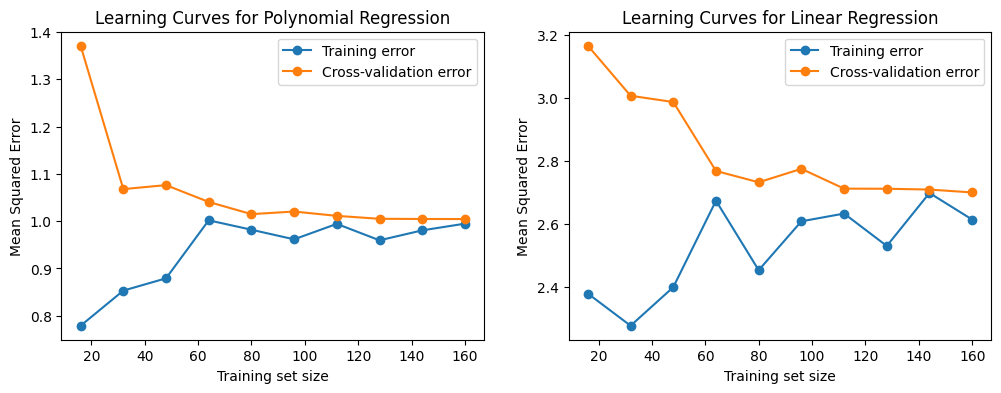

In [14]:
from sklearn.model_selection import learning_curve

# curvas de aprendizado para a regressão polinomial
train_sizes, train_scores, test_scores = learning_curve(
    lin_reg_poly, X_poly, y_noise.ravel(), cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
) # o modelo vai ser treinado com diferentes tamanhos de conjunto de treino. Para cada tamanho de conjunto o modelo é treinado 5 vezes (cv=5) e a média dos erros de treinamento e validação cruzada é calculada. 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_sizes, -train_scores.mean(axis=1), label='Training error', marker='o')
axes[0].plot(train_sizes, -test_scores.mean(axis=1), label='Cross-validation error', marker='o')
axes[0].set_xlabel("Training set size")
axes[0].set_ylabel("Mean Squared Error")
axes[0].set_title("Learning Curves for Polynomial Regression")
axes[0].legend()

# curvas de aprendizado para a regressão linear
train_sizes_lin, train_scores_lin, test_scores_lin = learning_curve(
    lin_reg, X, y_noise.ravel(), cv=5, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
)
axes[1].plot(train_sizes_lin, -train_scores_lin.mean(axis=1), label='Training error', marker='o')
axes[1].plot(train_sizes_lin, -test_scores_lin.mean(axis=1), label='Cross-validation error', marker='o')
axes[1].set_xlabel("Training set size")
axes[1].set_ylabel("Mean Squared Error")
axes[1].set_title("Learning Curves for Linear Regression")
axes[1].legend()

plt.show()


# Esse gap constante entre as curvas podem siginfiar overfitting... maior regularizacao ou mais dados de treinamento podem ajudar a reduzir esse gap.
# Adicionar dados ajuda pois isso dificulta o modelo aprender o ruido, forçando o modelo a aprender o padrão geral dos dados, em vez de se ajustar ao ruído específico do conjunto de treinamento.
# Se o problema é underfitting, adicionar mais dados não vai ajudar, pois o modelo já é muito simples para capturar a complexidade dos dados. Nesse caso, aumentar a complexidade do modelo 
# (por exemplo, usando um polinômio de grau mais alto) ou reduzir a regularização pode ajudar a melhorar o desempenho do modelo.

### Bias x Variance Tradeoff 

O erro de predicao de um modelo pode ser decomposto em 3 tipos:

- Vies (Bias): Esse tipo de erro tem uma direcao bem definida e é equivalente ao erro sistemático de uma amostra de dados. Nos modelos isso é representado por premissas erradas como assumir que os dados sao lineares quando nao sao. Uma quantidade alta desse erro leva a underfitting, ou seja, nao alinhamos o modelo nem aos dados de treino nem generalizamos. Esse erro geralmente esta relacionado a escolha do modelo pois assumimos coisas erradas ou nao assumimos nada ao escolher o modelo. Por exemplo escolhemos um modelo muito simples como linear para dados complexos polinomiais... nesses casos o modelo aprende uma regra muito simples que desloca as predicoes erroneamente para uma direcao.
(Vies reflete a incapacidade do modelo de capturar a estrutura real dos dados devido a simplicidade do modelo)

- Variancia (Variance): Esse tipo de erro acontece quando nosso modelo é muito complexo para nossos dados e a consequencia disso é que o modelo comeca a aprender o ruido dos dados como se fosse um padrao real... isso pode acontecer se usarmos modelos polinomiais de grau alto para dados simples. Modelos com alta variancia tendem a overfitting uma vez que aprendem o erro do treino que é aleatório fazendo que as predicoes fora do treino sejam muito dispersas (alta variancia).

- Erro irredutivel: Erro causado pelo processo de coleta dos dados, ou seja, erros de coleta ou pequenas variacoes na medicao e consequentemente esse erro nao pode ser reduzido pois se esse erro esta presente em todos as amostrar o modelo vai aprender... o erro aleatório dos dados, que é um erro sem direcao e imprevisivel é o principal componente do erro irredutivel. Esse erro só pode ser reduzido melhorando a qualidade da fonte dos dados pois ele é intriseco dos dados.

### Modelos Lineares Regularizados

Tornar um modelo mais simples é o primeiro passo para reduzir problemas de overfitting... mas e quando seu modelo já é linear e mesmo assim esta tendo esse problema ? isso é causada principalmente pelas premissas assumidas na regressão linear como por exemplo o fato das features serem linearmente independentes (Por causa da equação Normal e SVD)... se não for verdade podemos ter problemas numéricos. Alguma soluções tentam limitar o tamanho dos pesos para evitar um ajusto muito fino aos dados.

- Ridge Regression: No gradiente descendente adicionamos na loss um termo que representa a norma l2 do vetor (comprimento) de features w dividido pelo numero de linhas. Quanto maior a norma e maior o parametro de regularização maior vai ser a penalização na loss do modelo... Para soluções paramétricas de regressão temos uma soma de uma matriz *aA* que tem o mesmo proposito. A regularização ridge é basicamente uma bola em 3D (quando temos apenas 3 parametros) centralizada em 0 em que o raio dessa bola é inversamente proporcional com o parametro de regularização. Além disso, ele é sensivel a escala, ou seja, se as features não estiverem na mesma escala as maiores receberão mais atenção.

- Lasso Regression: Na lasso regression usamos norma l1 ao invés da normal l2. A consequencia disso é que ele não gera mais uma bola e sim um quadrado/diamante centralizado em 0. A lasso é uma função não derivavel e portanto seu grandiente é apenas um sinal de crescimento ou subida (-1 ou 1) mas sem tamanho. Isso faz com que qualquer passo no espaço tenha exatamente o mesmo tamanho fazendo com que o algortimo quando proximo do minimo varie muito para cima e para baixo (quicando) e demore para convergir ou talvez nem chegue a convergir... Uma vantagem do lasso é sua capacidade de tornar o espaço de features esparso, ou seja, ele zera facilmente totalmente os parametros de algumas features (o ridge não faz isso) e isso acontece exatamente pela gradiente constante já que se temos dois parametros w1=0.5 e w2=2, ambos os parametros vão ser reduzidos na mesma quantidade e consequentemente o w1 será zerado rapidamente primeiro.

- Elastic Net Regression: Nessa versão nos temos um parametro r de regularizacao... ponderamos a regularizacao ridge com r e a lasso com (1-r). Ele é o tradeoff entre os dois. 

In [ ]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_poly, y_noise)
print("Theta best (com ruído, Ridge Regression):", [ridge_reg.intercept_, ridge_reg.coef_])

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_poly, y_noise)
print("Theta best (com ruído, Lasso Regression):", [lasso_reg.intercept_, lasso_reg.coef_])

elastic_net_reg = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net_reg.fit(X_poly, y_noise)
print("Theta best (com ruído, Elastic Net Regression):", [elastic_net_reg.intercept_, elastic_net_reg.coef_])


Theta best (com ruído, Ridge Regression): [array([2.00663278]), array([1.10824982, 0.50481537])]
Theta best (com ruído, Lasso Regression): [array([2.05191596]), array([1.07407085, 0.48852087])]
Theta best (com ruído, Elastic Net Regression): [array([2.04061078]), array([1.07305566, 0.49246591])]


- Early Stopping: Early stoping também chamado de free lunch é outra forma de regularizar o modelo por meio de parar o treinamento quando a loss de validação volta a subir ou fica menor que uma quantidade definida. Existem varias tecnicas diferentes como esperar a loss subir K vezes consecutivas mas todas no final visam parar quando não valer mais a pena ou modelo estar degradando. Essa técnica funciona bem quando temos funções convexas ou simples que geralmente a loss de val subir significa piora do modelo... em espaços mais complexos como de uma rede neural essa técnica é complicada uma vez que podemos estar saindo de um minimo local.


In [ ]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.pipeline import Pipeline

train_X, val_X, train_y, val_y = train_test_split(X_poly, y_noise, test_size=0.2, random_state=42)

preprocessing = Pipeline([
    ("poly_features", PolynomialFeatures(degree=5, include_bias=False)),
    ("scaler", StandardScaler())
])

sgd_reg = SGDRegressor(random_state=42, penalty=None, eta0=0.01)
X_train_prepared = preprocessing.fit_transform(train_X)
X_val_prepared = preprocessing.transform(val_X)

best_valid_rmse = float("inf")
best_model = None

for epoch in range(1000):
    sgd_reg.partial_fit(X_train_prepared, train_y.ravel())
    val_predictions = sgd_reg.predict(X_val_prepared)
    valid_rmse = root_mean_squared_error(val_y, val_predictions)
    train_predictions = sgd_reg.predict(X_train_prepared)
    train_rmse = root_mean_squared_error(train_y, train_predictions)

    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}, Validation RMSE: {valid_rmse:.4f}, Training RMSE: {train_rmse:.4f}")

    if valid_rmse < best_valid_rmse:
        best_valid_rmse = valid_rmse
        best_model = deepcopy(sgd_reg)
        
        if epoch % 100 == 0:
            print(f"New best model found at epoch {epoch+1} with Validation RMSE: {valid_rmse:.4f}")

# nessa implementação o treino não para mas sempre salva o melhor modelo encontrado durante o processo de treinamento.
# O modelo é salvo sempre que o RMSE de validação melhora, garantindo que o melhor modelo seja mantido mesmo que o 
# treinamento continue por muitas épocas.


Epoch 1, Validation RMSE: 2.5919, Training RMSE: 2.2514
New best model found at epoch 1 with Validation RMSE: 2.5919
Epoch 101, Validation RMSE: 1.0043, Training RMSE: 0.9980
New best model found at epoch 101 with Validation RMSE: 1.0043
Epoch 201, Validation RMSE: 0.9951, Training RMSE: 0.9880
New best model found at epoch 201 with Validation RMSE: 0.9951
Epoch 301, Validation RMSE: 0.9940, Training RMSE: 0.9838
Epoch 401, Validation RMSE: 0.9951, Training RMSE: 0.9817
Epoch 501, Validation RMSE: 0.9968, Training RMSE: 0.9805
Epoch 601, Validation RMSE: 0.9984, Training RMSE: 0.9798
Epoch 701, Validation RMSE: 1.0000, Training RMSE: 0.9793
Epoch 801, Validation RMSE: 1.0013, Training RMSE: 0.9790
Epoch 901, Validation RMSE: 1.0024, Training RMSE: 0.9788


## Regressão Logistica

Ok temos um modelo de regressão... agora como podemos transformar isso em um classificador ? podemos ao invés de um estimar um valor continuo target podemos estimar a probabilidade de uma determiada classe. Se essa probalidade for maior que um threshold nos consideramos da classe.

- Estimando uma probabilidade binária: Para classificação binária podemos usar aquela mesma soma dos pesos w multiplicados pelas features x e colocar a saida em uma função sigmoid (sig(t) = 1 / (1+ e^-t)). A função simoid gera um valor gera uma probabilidade de 0.5 se o score previstos pelos pesos w é 0, uma probabilidade de 1 se o score gerado é muito grande e uma probabilidade de 0 se o score gerado é muito pequeno. Então basicamente esse modelo é uma regressão linear em que a previsão passa por uma função sigmoid e em seguida a saida dessa função sigmoid é avaliada por uma loss. Qual loss ?

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

- Entropia Binária (log loss): Para quantizar o erro aqui usamos basicamente o negativo da função logatimica. Log(1) é 0 e conforme vamos reduzindo o valor da entrada do Log o valor do log vai indo para -1, por exemplo o log(0.1) = 1 (Quanto mais proximo o valor logaritmado esta de 0, maior o modulo dele fica). Usando essa lógica temos dois casos... a resposta correta é 1 então temos que penalizar mais se a previsão esta menor que 1. E se a previsão correta é 0, temos que penalizar mais as previções em que a probabilidade esta maior que 0. Logo, se y_real = 0, nossa loss será -log(1 - y_predito) que cresce quando y_predito é proximo de 1 mas a probabilidade real é 0. Se y_real = 1, nossa loss será -log(y_predito) que cresce quando y_predito é proximo de 0 mas a probabilidade real é 1. Se juntarmos os dois casos em uma formula e fizermos isso para todas as instancias do treino(batch) e calcularmos a media temos a loss completa:

$$
L = -\frac{1}{n} \sum_{i=1}^{n} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]
$$

Uma noticia ruim dessa loss é que não existe uma formula fechada direta igual o MSE (com Normal e SVD) então necessáriamente temos que usar algoritmos de otimização como gradiente descendente. Uma boa noticia é que a função é igualmente convexa como o MSE então se otimizarmos tempo suficiente os parametros eles vão convergir para o minimo global. Quando usamos a log loss estamos assumindo algumas coisas sobre os dados... uma delas é que os dados seguem a distribuição de bernoulli em que os dados são modelados como sim e não.

- Decision Barrier (barreira de decisão): È a linha, plano ou elemento n-dimensional que tenta separar as classes no espaço. Ela por padrão usa 50% em que instancia com probabilidade proxima de 50% estão inseguras e longe de 50% estão confiantes... o threshold que escolhemos é a decisão de quando ou não dizer que é de uma classe e consequentemente quanto maior ele mais deslocamos a barreira de decisão para direita.

- Regressão Logistica Multinomial: Nessa versão da regressão nos generalizamos para classificação multiclasse... nesse caso se temos K classes então nossos parametros são uma matriz KxN em que temos um conjunto de N parametros para cada classe. A saida será um vetor de dimensão Kx1 (pois multiplicamos por Nx1) em que cada posição K representa o logit daquela classe. Usamos então softmax para normalizar e transformar em probabilidades. Depois pegamos a classe com maior probabilidade...

$$
\sigma(\mathbf{z})_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}
$$

Usamos de loss a generalização da entropia binária, chamada de entropia cruzada: 

$$
J(\mathbf{w}) = -\sum_{k=1}^{K} y_k \log(\hat{p}_k)
$$

Esse tipo de classificação só funciona com problemas multiclasse. (Não multilabel ou multioutput)